# CreditShield: Preprocessing Audit EDA

This notebook audits preprocessing outputs and assumptions **before modeling** using the same `DataLoader` and `CONFIG` used by the training pipeline.

In [ ]:
import sys
from pathlib import Path

# Find project root by walking upward until training config exists
cwd = Path.cwd().resolve()
PROJECT_ROOT = None
for p in [cwd] + list(cwd.parents):
    if (p / "credit-risk-prediction-project" / "training" / "config.py").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate credit-risk-prediction-project/training/config.py")

TRAINING_DIR = PROJECT_ROOT / "credit-risk-prediction-project" / "training"
SRC_DIR = TRAINING_DIR / "src"

sys.path.insert(0, str(TRAINING_DIR))
sys.path.insert(0, str(SRC_DIR))

from config import CONFIG
from load_data import DataLoader

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAINING_DIR:", TRAINING_DIR)

PROJECT_ROOT: /Users/priscillaashleywijaya/Desktop/General/NUS_Fintech_Society/capstone/src/CreditShield
TRAINING_DIR: /Users/priscillaashleywijaya/Desktop/General/NUS_Fintech_Society/capstone/src/CreditShield/credit-risk-prediction-project/training


## 1) Load Filtered Data and Define Target

Loads data through the project `DataLoader`, then applies target definition exactly as the modeling pipeline does.

In [6]:
import kagglehub
from pathlib import Path
from copy import deepcopy

dataset_dir = Path(kagglehub.dataset_download("wordsforthewise/lending-club"))
print("Dataset dir:", dataset_dir)

# Find real CSV files only
all_csvs = [p for p in dataset_dir.rglob("*.csv") if p.is_file()]
print(f"Found {len(all_csvs)} CSV files")

# Prefer exact target filename
target = [p for p in all_csvs if p.name == "accepted_2007_to_2018Q4.csv"]
if target:
    data_csv = target[0]
else:
    # fallback: choose any accepted_* CSV file
    accepted = [p for p in all_csvs if "accepted" in p.name.lower()]
    if not accepted:
        raise FileNotFoundError(f"No accepted*.csv file found under {dataset_dir}")
    data_csv = accepted[0]

print("Using file:", data_csv, "| is_file:", data_csv.is_file())

CONFIG_LOCAL = deepcopy(CONFIG)
CONFIG_LOCAL["paths"]["raw_data"] = str(data_csv.resolve())

loader = DataLoader(CONFIG_LOCAL)
df = loader.load_and_filter_data()
df = loader.define_target(df, strategy=CONFIG_LOCAL["target_settings"]["default_strategy"])


Dataset dir: /Users/priscillaashleywijaya/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3
Found 2 CSV files
Using file: /Users/priscillaashleywijaya/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv | is_file: True
Loading data according to paper methodology...
Loading data with memory optimization...
Loading 81 of 81 essential columns
Error with optimized loading: cannot safely convert passed user dtype of int8 for float64 dtyped data in column 25
Falling back to standard loading...
✓ Loaded 2,260,701 rows, 81 columns
✓ Filtered to years [2013, 2014]: 370,443 rows
✓ Removed incomplete loans: 358,244 remaining
Date range: 2013-01-01 to 2014-12-01
Defining target using 'business' strategy...
  Default statuses: ['Charged Off', 'Default', 'Late (31-120 days)']
  Good statuses: ['Fully Paid']
✓ Target defined:
  Total loans: 358,244
  Defaults: 62,523 (17.45%)
  Good/Default ratio: 4.7:1
  Removed 0 

In [7]:
target_strategy = CONFIG_LOCAL.get('target_settings', {}).get('default_strategy', 'business')
df = loader.define_target(df, strategy=target_strategy)

# Sampling guard for faster audit runs
# 1) Respect config sample_size if set
# 2) Otherwise use optional notebook-level sampling
USE_SAMPLE = True
MAX_SAMPLE_ROWS = 200000
sample_size_cfg = CONFIG_LOCAL.get('data_settings', {}).get('sample_size', None)

if sample_size_cfg is not None and len(df) > sample_size_cfg:
    df = df.sample(sample_size_cfg, random_state=42).copy()
    print(f'Applied config sample_size={sample_size_cfg:,}. New shape: {df.shape}')
elif sample_size_cfg is None and USE_SAMPLE and len(df) > MAX_SAMPLE_ROWS:
    df = df.sample(MAX_SAMPLE_ROWS, random_state=42).copy()
    print(f'Applied notebook sample size={MAX_SAMPLE_ROWS:,}. New shape: {df.shape}')
else:
    print(f'No additional sampling applied. Shape: {df.shape}')

Defining target using 'business' strategy...
  Default statuses: ['Charged Off', 'Default', 'Late (31-120 days)']
  Good statuses: ['Fully Paid']
✓ Target defined:
  Total loans: 358,244
  Defaults: 62,523 (17.45%)
  Good/Default ratio: 4.7:1
  Removed 0 loans with unknown status
Applied notebook sample size=200,000. New shape: (200000, 84)


## 2) Dataset Overview

Basic checks on shape, column count, temporal coverage, and class balance.

In [8]:
print('Shape:', df.shape)
print('Column count:', len(df.columns))

if 'issue_year' not in df.columns and 'issue_d' in df.columns:
    df['issue_date'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
    df['issue_year'] = df['issue_date'].dt.year

if 'issue_year' in df.columns:
    years_dist = df['issue_year'].value_counts(dropna=False).sort_index()
    print('\nYears distribution:')
    print(years_dist)

if 'issue_date' in df.columns:
    print('\nDate range:', df['issue_date'].min(), 'to', df['issue_date'].max())

if 'target' in df.columns:
    target_dist = df['target'].value_counts(dropna=False).sort_index()
    default_rate = df['target'].mean()
    print('\nTarget distribution:')
    print(target_dist)
    print(f'Default rate: {default_rate:.2%}')

Shape: (200000, 84)
Column count: 84

Years distribution:
issue_year
2013.0     75419
2014.0    124581
Name: count, dtype: int64

Date range: 2013-01-01 00:00:00 to 2014-12-01 00:00:00

Target distribution:
target
0    165253
1     34747
Name: count, dtype: int64
Default rate: 17.37%


## 3) Missing Values Audit

Identifies where preprocessing may still face high NA burden.

Missing % by column (descending):


,missing_pct
mths_since_last_record,84.313
mths_since_last_major_derog,74.733
mths_since_last_delinq,52.023
mths_since_recent_inq,9.722
emp_title,5.922
...,...
total_pymnt,0.000
out_prncp_inv,0.000
out_prncp,0.000
initial_list_status,0.000


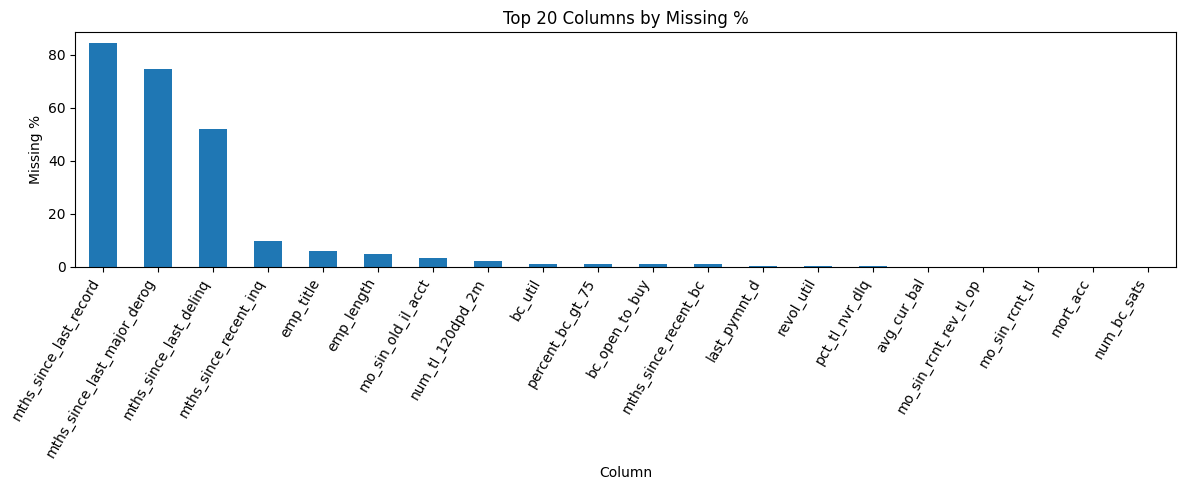

Columns with >30% missing (3):
['mths_since_last_record', 'mths_since_last_major_derog', 'mths_since_last_delinq']


In [9]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = missing_pct.to_frame('missing_pct')

print('Missing % by column (descending):')
display(missing_table)

top_missing = missing_pct.head(20)
plt.figure(figsize=(12, 5))
top_missing.plot(kind='bar', color='tab:blue')
plt.title('Top 20 Columns by Missing %')
plt.ylabel('Missing %')
plt.xlabel('Column')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

high_missing_cols = missing_pct[missing_pct > 30].index.tolist()
print(f'Columns with >30% missing ({len(high_missing_cols)}):')
print(high_missing_cols)

In [18]:
display(df['mths_since_last_record'].unique())
display(df['mths_since_last_major_derog'].unique())
display(df['mths_since_last_delinq'].unique())

array([ nan,  91., 119.,  82.,  56.,  85., 112.,  98.,  86.,  57.,  36.,
        52., 116.,  58.,  49., 109.,  92.,  71.,  31.,  73.,   7.,  64.,
        60.,  76., 105.,  23.,  97.,  69.,  93., 110.,  62.,  53., 107.,
         8.,  66., 118.,  29.,  50.,  95.,  40., 104., 103.,  51., 106.,
        65.,  87.,  33., 101.,  46.,  39.,  81.,  41.,  63., 102.,  80.,
       115., 117., 114.,  68.,   6.,  90.,  70., 100., 108.,  48., 113.,
        45.,  77.,  43.,  17.,  27.,  61.,  96.,  26., 111.,  55.,  25.,
        99.,  84.,  79.,  94.,  14.,  19.,   9.,  72.,  88.,  37.,  89.,
        83.,  47.,  32.,  78.,  54.,   4.,  44.,  30.,  42.,  59.,  75.,
        15.,  74.,  21.,  38.,  22.,  13.,  28.,  35.,  16.,  12.,  10.,
         5.,  20.,  67.,  24.,  18.,  34.,  11.,   1.,   3.,   2.,   0.])

array([ nan,  12.,  70.,  63.,  18.,  81.,  20.,  25.,  39.,  51.,  47.,
        75.,  37.,  57.,  59.,  46.,  52.,  32.,  53.,  26.,  71.,  60.,
        36.,  72.,  49.,  35.,  55.,  43.,  48.,  58.,  65.,  44.,  67.,
        40.,  30.,  62.,  24.,  56.,  13.,  69.,   9.,  78.,  82.,  29.,
         5.,  54.,  28.,  10.,  21.,  27.,  64.,  19.,  14.,  41.,  76.,
         4.,  11.,  42.,   1.,  15.,  38.,   2.,  50.,  80.,  74.,  61.,
         8.,  31.,  68.,  45.,  77.,  79.,  23.,  17.,  34.,  33.,   6.,
        66.,  96.,   7.,  16.,   3.,  22.,  73., 149.,   0.,  88., 135.,
       162., 147., 106.,  84.,  85., 133.,  86.,  87., 165.,  83., 104.,
       130.,  92.,  97., 115.,  89., 102.,  91., 154.,  99., 119., 105.,
       140., 108.,  98.,  94., 131.,  93., 101., 188.,  90., 107.,  95.,
       113., 118., 124., 109., 120., 141., 122., 114., 111., 112., 136.,
       121., 148., 146., 103., 110., 129., 139., 156.])

array([  9.,  nan,  63.,   3.,  55.,  49.,   6.,  18.,  20.,  38.,  81.,
        62.,  14.,   5.,  40.,  82.,  51.,  46.,  15.,  75.,  27.,  37.,
        57.,  59.,  22.,   7.,  11.,  21.,  26.,  45.,  72.,  79.,  32.,
        50.,  35.,  25.,  12.,  13.,  60.,  36.,  44.,  68.,  39.,  33.,
        42.,   8.,  78.,  17.,  48.,  10.,   4.,  58.,  24.,  65.,   1.,
        30.,  53.,  43.,  52.,  56.,  74.,  61.,  69.,  41.,  23.,  29.,
        16.,  54.,  28.,  19.,  70.,  47.,  64.,  67.,  31.,  66.,  76.,
         2.,  34.,  80.,  71.,  77.,  96.,  73., 149.,   0.,  88., 135.,
       106.,  84.,  85., 133.,  86.,  83.,  87., 130.,  92.,  89., 102.,
        97., 104.,  91.,  94.,  99., 131.,  93., 105., 119., 188.,  90.,
       101., 113., 115., 124.,  98., 120., 141.,  95., 122., 114., 136.,
       121., 148., 146., 129., 139., 156., 107., 140., 103.])

In [20]:
display(df.groupby('target')['mths_since_last_record'].describe().rename_axis('record'))
display(df.groupby('target')['mths_since_last_major_derog'].describe().rename_axis('major_derog'))
display(df.groupby('target')['mths_since_last_delinq'].describe().rename_axis('delinq'))

,count,mean,std,min,25%,50%,75%,max
record,,,,,,,,
0,25593.0,74.574376,28.799329,0.0,53.0,75.0,101.0,119.0
1,5781.0,75.931673,28.377857,1.0,55.0,77.0,102.0,119.0


,count,mean,std,min,25%,50%,75%,max
major_derog,,,,,,,,
0,41191.0,42.011192,20.754356,0.0,25.0,42.0,58.0,188.0
1,9343.0,42.765172,21.141901,0.0,26.0,43.0,60.0,147.0


,count,mean,std,min,25%,50%,75%,max
delinq,,,,,,,,
0,79017.0,33.805991,21.629966,0.0,15.0,31.0,49.0,188.0
1,16937.0,33.590660,21.889286,0.0,15.0,30.0,49.0,129.0


## 4) Leakage Sanity Check

Checks whether known post-origination / leakage columns are present.

In [10]:
leakage_cols = {
    'last_pymnt_d', 'total_pymnt', 'recoveries', 'collection_recovery_fee',
    'out_prncp', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'last_pymnt_amnt'
}

present_leakage = leakage_cols.intersection(set(df.columns))
try:
    assert len(present_leakage) == 0, f'Leakage columns present: {sorted(present_leakage)}'
    print('Leakage check passed: no known leakage columns found.')
except AssertionError as e:
    print('WARNING:', e)

## 5) Outlier and Heavy-Tail Checks

Summarizes key numeric fields, visualizes distributions, and flags suspicious values.

Summary stats (min, p1, median, p99, max):


,min,p1,median,p99,max
column,,,,,
annual_inc,3000.0,19500.00,64000.00,245000.00,6100000.00
dti,0.0,2.23,17.23,34.84,39.99
revol_bal,0.0,558.00,11900.00,83693.09,2568995.00
revol_util,0.0,4.00,57.50,98.00,366.60
loan_amnt,1000.0,2000.00,12800.00,35000.00,35000.00
int_rate,6.0,6.03,13.68,24.99,26.06


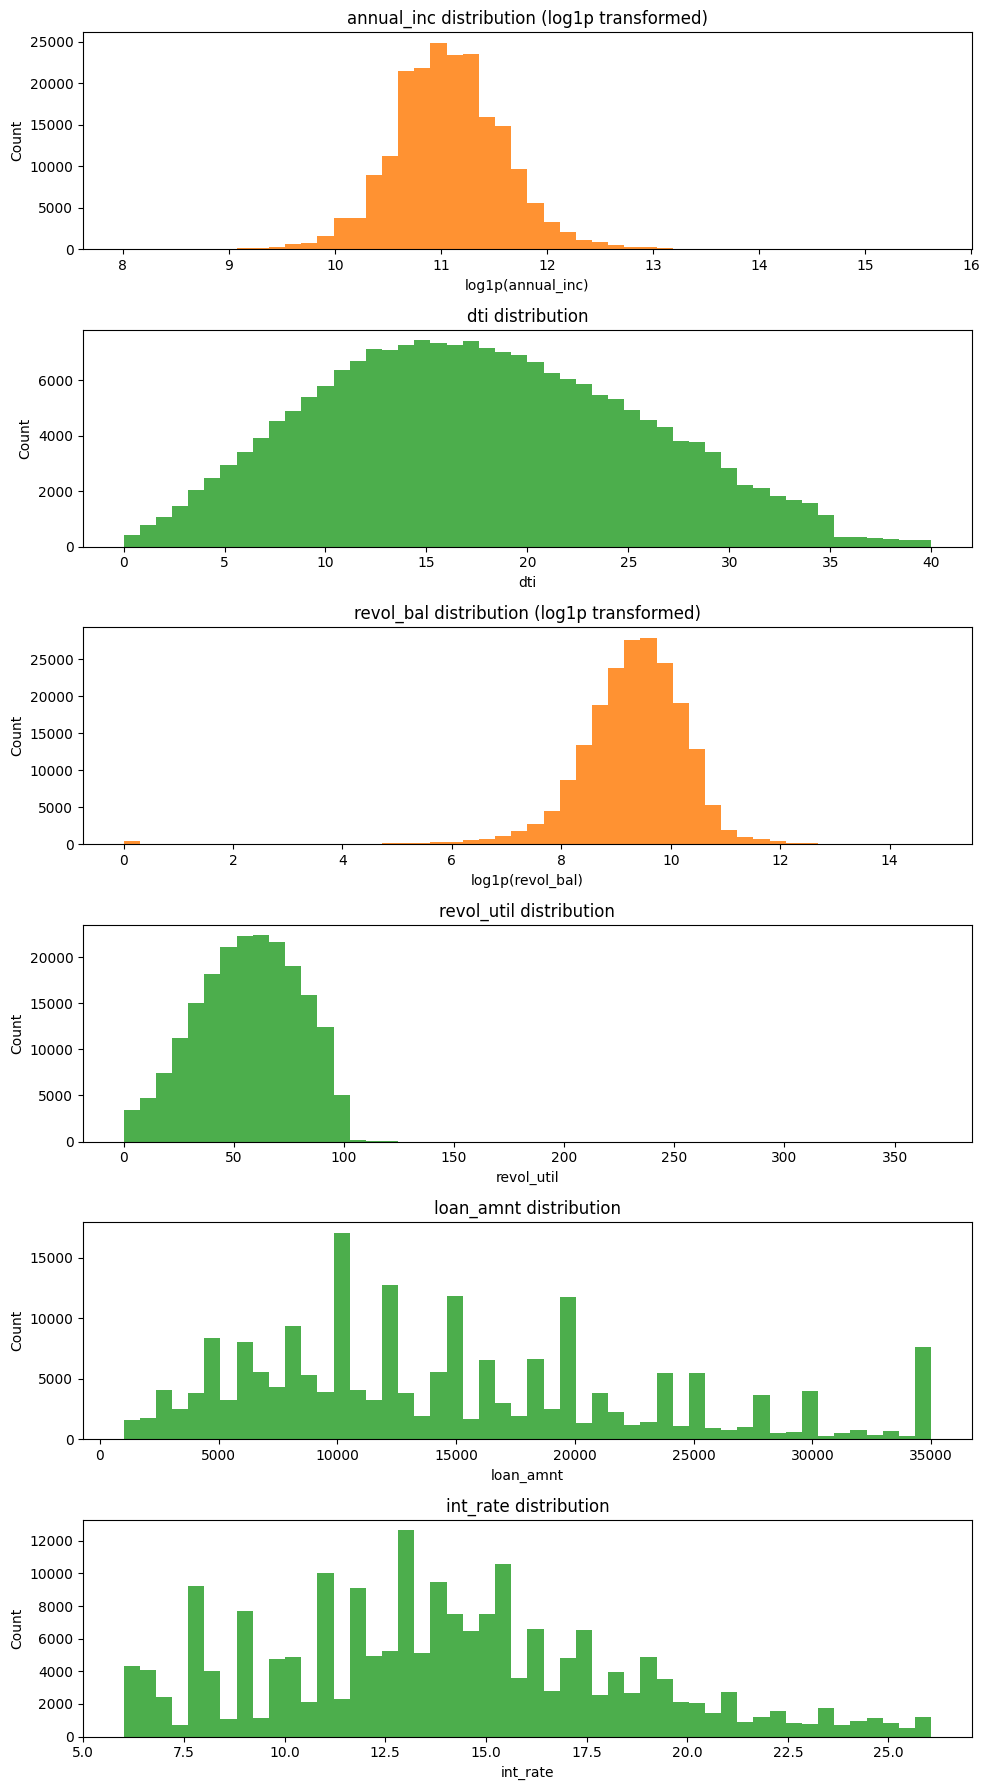

Suspicious value counts:
{'annual_inc <= 0': 0, 'dti < 0': 0, 'revol_util outside [0, 100]': 641}


In [11]:
candidate_cols = ['annual_inc', 'dti', 'revol_bal', 'revol_util', 'loan_amnt', 'int_rate']
num_cols = [c for c in candidate_cols if c in df.columns]

if num_cols:
    summary_rows = []
    for col in num_cols:
        s = pd.to_numeric(df[col], errors='coerce')
        summary_rows.append({
            'column': col,
            'min': s.min(),
            'p1': s.quantile(0.01),
            'median': s.median(),
            'p99': s.quantile(0.99),
            'max': s.max(),
        })

    summary_df = pd.DataFrame(summary_rows).set_index('column')
    print('Summary stats (min, p1, median, p99, max):')
    display(summary_df)

    heavy_tail_cols = {'annual_inc', 'revol_bal'}
    n = len(num_cols)
    fig, axes = plt.subplots(n, 1, figsize=(10, max(3 * n, 4)))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, num_cols):
        s = pd.to_numeric(df[col], errors='coerce').dropna()
        if col in heavy_tail_cols:
            plot_vals = np.log1p(s.clip(lower=0))
            ax.hist(plot_vals, bins=50, color='tab:orange', alpha=0.85)
            ax.set_title(f'{col} distribution (log1p transformed)')
            ax.set_xlabel(f'log1p({col})')
        else:
            ax.hist(s, bins=50, color='tab:green', alpha=0.85)
            ax.set_title(f'{col} distribution')
            ax.set_xlabel(col)
        ax.set_ylabel('Count')

    plt.tight_layout()
    plt.show()

    suspicious = {}
    if 'annual_inc' in df.columns:
        suspicious['annual_inc <= 0'] = int((pd.to_numeric(df['annual_inc'], errors='coerce') <= 0).sum())
    if 'dti' in df.columns:
        suspicious['dti < 0'] = int((pd.to_numeric(df['dti'], errors='coerce') < 0).sum())
    if 'revol_util' in df.columns:
        ru = pd.to_numeric(df['revol_util'], errors='coerce')
        suspicious['revol_util outside [0, 100]'] = int(((ru < 0) | (ru > 100)).sum())

    print('Suspicious value counts:')
    print(suspicious if suspicious else 'No suspicious checks applicable.')
else:
    print('No key numeric columns found for outlier checks.')

## 6) Temporal Drift Check

Tracks default-rate movement over origination years.

Default rate by year:
issue_year
2013.0    15.53%
2014.0    18.49%
Name: target, dtype: object


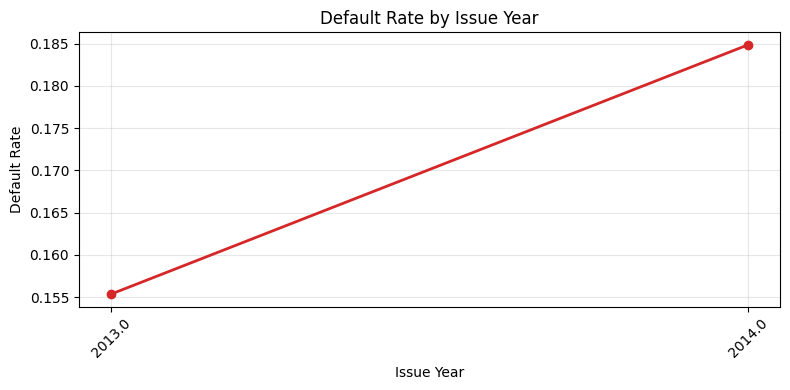

In [12]:
if 'issue_year' not in df.columns and 'issue_d' in df.columns:
    df['issue_date'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
    df['issue_year'] = df['issue_date'].dt.year

if 'issue_year' in df.columns and 'target' in df.columns:
    drift = df.groupby('issue_year', dropna=False)['target'].mean().sort_index()
    print('Default rate by year:')
    print((drift * 100).round(2).astype(str) + '%')

    plt.figure(figsize=(8, 4))
    plt.plot(drift.index.astype(str), drift.values, marker='o', linewidth=2, color='tab:red')
    plt.title('Default Rate by Issue Year')
    plt.xlabel('Issue Year')
    plt.ylabel('Default Rate')
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Cannot compute temporal drift: issue year or target not available.')

## 7) Split Integrity Checks

Runs the loader's time-based split and compares split sizes, default rates, and train-vs-test feature means.

In [13]:
val_ratio = CONFIG.get('training', {}).get('val_size', 0.15)
test_ratio = CONFIG.get('training', {}).get('test_size', 0.15)
train_ratio = 1 - val_ratio - test_ratio
if train_ratio <= 0:
    train_ratio, val_ratio = 0.7, 0.15

train_df, val_df, test_df = loader.time_based_split(df, train_ratio=train_ratio, val_ratio=val_ratio)

def split_summary(name, split_df):
    dr = split_df['target'].mean() if 'target' in split_df.columns else np.nan
    print(f'{name}: n={len(split_df):,}, default_rate={dr:.2%}')

split_summary('Train', train_df)
split_summary('Validation', val_df)
split_summary('Test', test_df)

compare_cols = [c for c in ['annual_inc', 'dti', 'revol_bal', 'revol_util', 'loan_amnt', 'int_rate'] if c in df.columns]
if compare_cols:
    rows = []
    for c in compare_cols:
        tr_mean = pd.to_numeric(train_df[c], errors='coerce').mean()
        te_mean = pd.to_numeric(test_df[c], errors='coerce').mean()
        rows.append({
            'feature': c,
            'train_mean': tr_mean,
            'test_mean': te_mean,
            'pct_diff_vs_train': ((te_mean - tr_mean) / tr_mean * 100) if pd.notna(tr_mean) and tr_mean != 0 else np.nan
        })
    compare_df = pd.DataFrame(rows).set_index('feature')
    print('\nTrain vs Test mean comparison:')
    display(compare_df)
else:
    print('No key numeric columns found for mean comparison.')


✓ Time-based split completed:
  Training: 129,999 loans (2013-01-01 to 2014-06-01)
  Validation: 30,000 loans (2014-06-01 to 2014-09-01)
  Testing: 40,001 loans (2014-09-01 to 2014-12-01)
Train: n=129,999, default_rate=16.36%
Validation: n=30,000, default_rate=19.12%
Test: n=40,001, default_rate=19.36%

Train vs Test mean comparison:


,train_mean,test_mean,pct_diff_vs_train
feature,,,
annual_inc,73968.439132,73725.478364,-0.328465
dti,17.281644,18.607057,7.669486
revol_bal,16251.265687,17210.321967,5.901425
revol_util,57.314790,55.305221,-3.506197
loan_amnt,14704.860037,14457.082323,-1.685006
int_rate,14.355754,13.008601,-9.384064


## 8) Findings & Recommendations

Use this section to record audit outcomes before feature engineering/model training:

- Missingness: _[Which columns exceed acceptable NA thresholds, and how to handle them?]_
- Leakage: _[Any post-origination variables still present?]_
- Outliers/Data quality: _[Which suspicious values need capping/filtering/rules?]_
- Temporal stability: _[Is default rate stable enough, or is drift material?]_
- Split integrity: _[Are train/val/test distributions reasonably consistent?]_
- Action items before modeling: _[Concrete preprocessing changes to implement.]_